In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

results_path = Path(r"C:\Nikita\FraudDetectionSystem\FraudDetection.ML\bin\Debug\net9.0\Results")

print("Results folder found:", results_path.exists())

Results folder found: True


In [2]:
model_df = pd.read_csv(
    results_path / "model_comparison.csv"
)

confusion_df = pd.read_csv(
    results_path / "confusion_matrix.csv"
)

print("Model Comparison")
display(model_df)

print("Confusion Matrix")
display(confusion_df)

Model Comparison


,Model,Accuracy,Precision,Recall,F1Score,AUC
0,FastTree,99.99,99.70,99.9,99.80,100.00
1,LightGBM,99.99,99.90,99.7,99.80,100.00
2,SDCA,1.99,1.99,100.0,3.89,47.79


Confusion Matrix


,Metric,Value
0,True Positive,1978
1,True Negative,97901
2,False Positive,3
3,False Negative,5


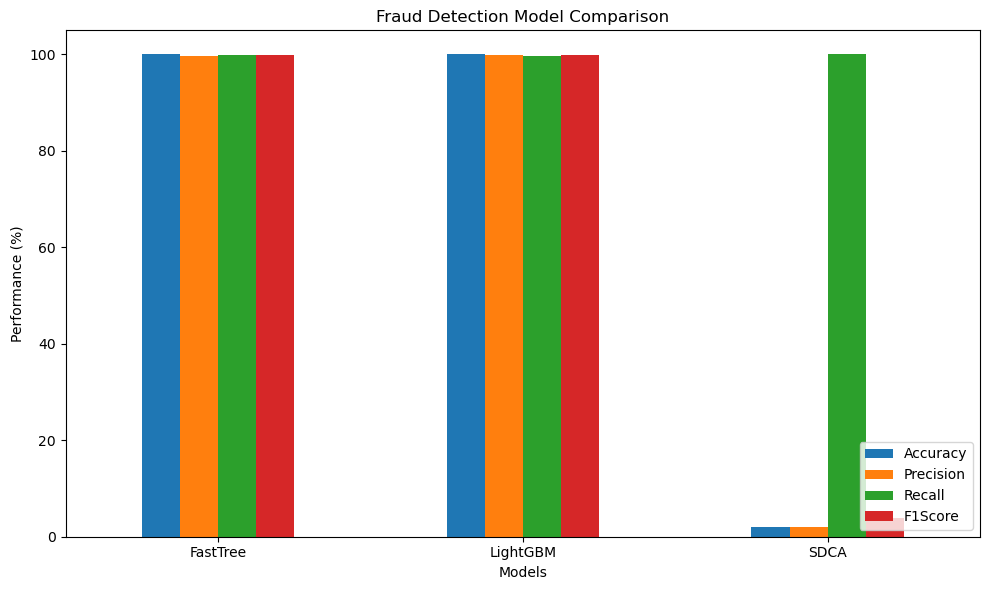

In [3]:
metrics = ["Accuracy", "Precision", "Recall", "F1Score"]

plot_df = model_df.set_index("Model")[metrics]

ax = plot_df.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Fraud Detection Model Comparison")
plt.ylabel("Performance (%)")
plt.xlabel("Models")
plt.xticks(rotation=0)

plt.legend(
    loc="lower right"
)

plt.tight_layout()

plt.savefig(
    results_path / "model_comparison_chart.pdf",
    bbox_inches="tight"
)

plt.show()

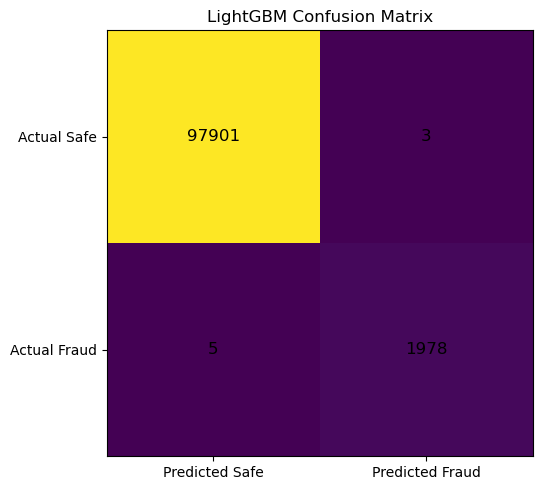

In [4]:
import numpy as np

tp = confusion_df.loc[
    confusion_df["Metric"] == "True Positive",
    "Value"
].values[0]

tn = confusion_df.loc[
    confusion_df["Metric"] == "True Negative",
    "Value"
].values[0]

fp = confusion_df.loc[
    confusion_df["Metric"] == "False Positive",
    "Value"
].values[0]

fn = confusion_df.loc[
    confusion_df["Metric"] == "False Negative",
    "Value"
].values[0]

matrix = np.array([
    [tn, fp],
    [fn, tp]
])

plt.figure(figsize=(6,5))

plt.imshow(matrix)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            f"{matrix[i,j]}",
            ha="center",
            va="center",
            fontsize=12
        )

plt.xticks(
    [0,1],
    ["Predicted Safe", "Predicted Fraud"]
)

plt.yticks(
    [0,1],
    ["Actual Safe", "Actual Fraud"]
)

plt.title("LightGBM Confusion Matrix")

plt.tight_layout()

plt.savefig(
    results_path / "confusion_matrix.pdf",
    bbox_inches="tight"
)

plt.show()

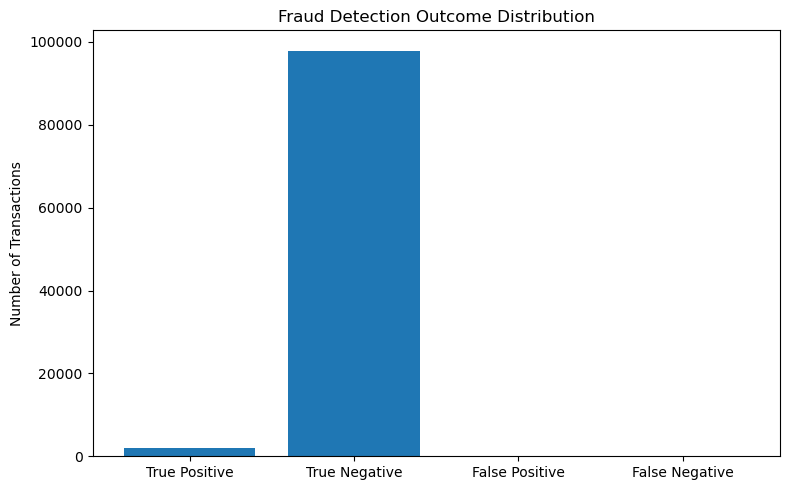

In [5]:
labels = [
    "True Positive",
    "True Negative",
    "False Positive",
    "False Negative"
]

values = [
    1978,
    97901,
    3,
    5
]

plt.figure(figsize=(8,5))

plt.bar(labels, values)

plt.title("Fraud Detection Outcome Distribution")
plt.ylabel("Number of Transactions")

plt.tight_layout()

plt.savefig(
    results_path / "fraud_distribution.pdf",
    bbox_inches="tight"
)

plt.show()

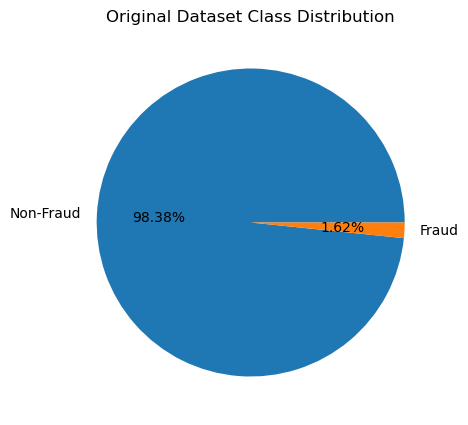

In [6]:
labels = ["Non-Fraud", "Fraud"]
values = [295242, 4871]

plt.figure(figsize=(6,5))

plt.pie(
    values,
    labels=labels,
    autopct="%1.2f%%"
)

plt.title("Original Dataset Class Distribution")

plt.savefig(
    results_path / "class_distribution.pdf",
    bbox_inches="tight"
)

plt.show()

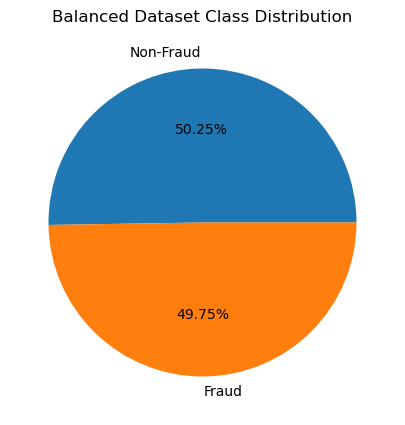

In [7]:
labels = ["Non-Fraud", "Fraud"]
values = [295242, 292260]

plt.figure(figsize=(6,5))

plt.pie(
    values,
    labels=labels,
    autopct="%1.2f%%"
)

plt.title("Balanced Dataset Class Distribution")

plt.savefig(
    results_path / "balanced_class_distribution.pdf",
    bbox_inches="tight"
)

plt.show()